Dataset Summary:
      Set  Class  Count
0  train   bird   1414
1  train  drone   1248
2  valid   bird    217
3  valid  drone    225
4   test   bird    121
5   test  drone     94


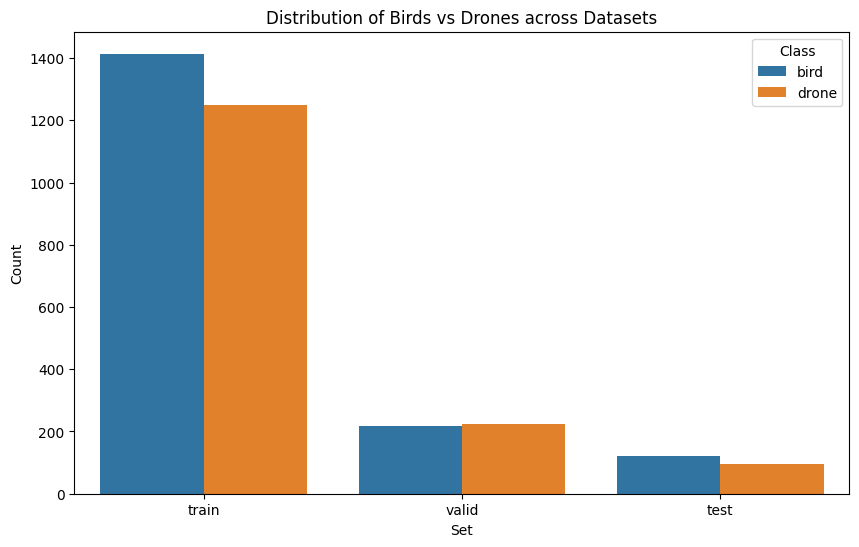

In [1]:
# 1. Dataset Inspection & Class Imbalance      -        Understand the Dataset

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define your dataset path
base_dir = 'D:/Python_Code/Projects_In_Course_Time/Project-5_AerialObjectClassification&Detection/' # Update this to your local path

train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

sets = ['train', 'valid', 'test']
classes = ['bird', 'drone']

# 1. Inspect Folder Structure & Check Numbers
data_counts = []

for s in sets:
    for c in classes:
        path = os.path.join(base_dir, s, c)
        count = len(os.listdir(path))
        data_counts.append({'Set': s, 'Class': c, 'Count': count})

df = pd.DataFrame(data_counts)
print("Dataset Summary:\n", df)

# 2. Identify Class Imbalance (Visualization)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Set', y='Count', hue='Class')
plt.title('Distribution of Birds vs Drones across Datasets')
plt.show()

In [ ]:
%pip install pandas

In [ ]:
%pip install matplotlib seaborn scikit-learn pillow


In [6]:
import os

def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        # Calculate the depth to indent the output
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        # Print the directory name
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        # Optionally show the count of files in that folder instead of listing every file
        if files:
            print(f"{subindent}({len(files)} images)")

# Replace with the actual path to your downloaded dataset
dataset_path = 'D:/Python_Code/Projects_In_Course_Time/Project-5_AerialObjectClassification&Detection/'
list_files(dataset_path)

/
    (8 images)
.ipynb_checkpoints/
    (2 images)
test/
    bird/
        (121 images)
    drone/
        (94 images)
train/
    bird/
        (1414 images)
    drone/
        (1248 images)
valid/
    bird/
        (217 images)
    drone/
        (225 images)


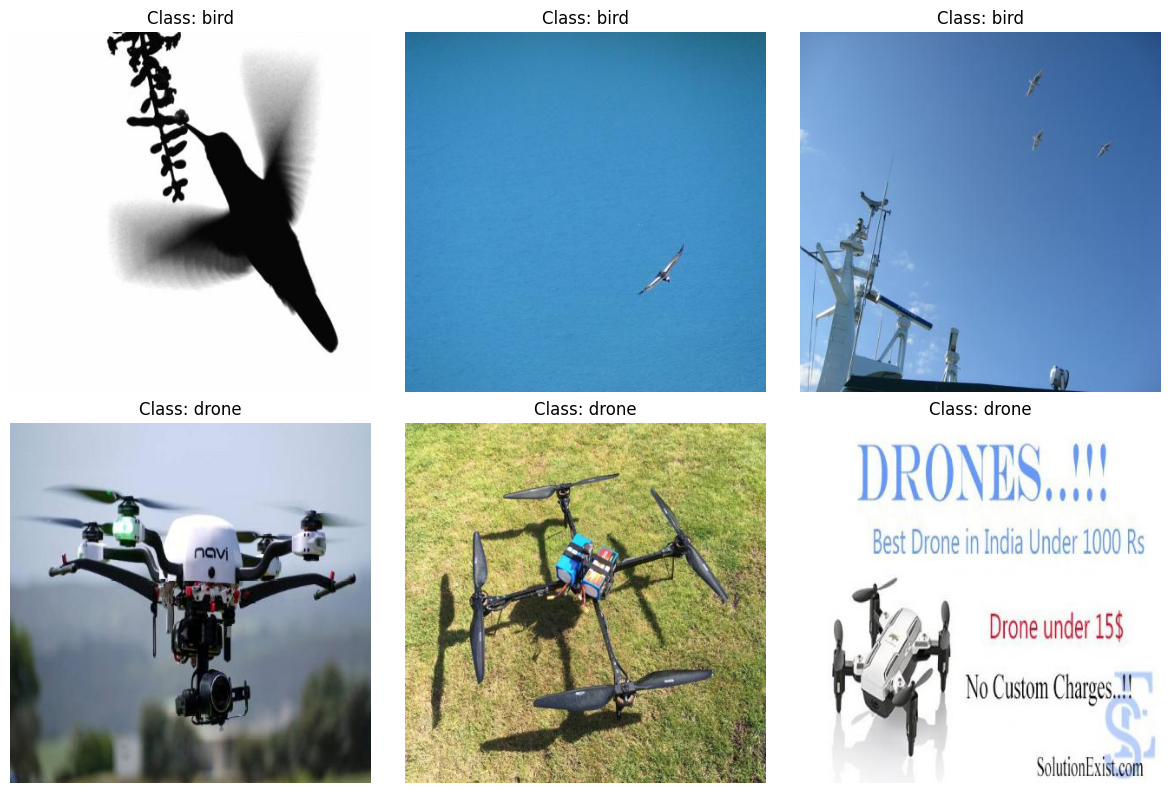

In [7]:
# 2. Visualize Sample Images

import cv2
import random

def visualize_samples(base_path, set_type='train', num_samples=3):
    plt.figure(figsize=(12, 8))
    
    for i, label in enumerate(classes):
        folder_path = os.path.join(base_path, set_type, label)
        sample_images = random.sample(os.listdir(folder_path), num_samples)
        
        for j, img_name in enumerate(sample_images):
            plt.subplot(len(classes), num_samples, i * num_samples + j + 1)
            img_path = os.path.join(folder_path, img_name)
            
            # Load and convert BGR to RGB
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.imshow(img)
            plt.title(f"Class: {label}")
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_samples(base_dir)

In [ ]:
%pip install opencv-python

In [8]:
# 2. Data Preprocessing

# Implementation: TensorFlow/Keras Approach

import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array, load_img

def preprocess_tf(image_path):
    # 1. Resize images to 224x224 
    img = load_img(image_path, target_size=(224, 224))
    
    # 2. Convert to array
    img_array = img_to_array(img)
    
    # 3. Apply model-specific scaling and normalization [cite: 43, 47]
    # For many models, this handles the [0, 1] or [-1, 1] scaling automatically
    img_preprocessed = preprocess_input(img_array)
    
    return img_preprocessed

In [10]:
import sys
print("Python Executable:", sys.executable)

try:
    import tensorflow as tf
    print("✅ TensorFlow successfully imported!")
    print("TensorFlow Version:", tf.__version__)
except ModuleNotFoundError:
    print("❌ TensorFlow is still missing from this specific environment path.")

Python Executable: C:\Users\bless\miniconda3\python.exe
✅ TensorFlow successfully imported!
TensorFlow Version: 2.21.0


In [ ]:
%pip install tensorflow

In [9]:
#  3. Data Augmentation
# Implementation: TensorFlow/Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Initialize the generator with the required transformations
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Preprocessing: Normalization [cite: 43]
    rotation_range=30,        # Transformation: Rotation
    width_shift_range=0.2,    # Transformation: Horizontal Shifting
    height_shift_range=0.2,   # Transformation: Vertical Shifting
    shear_range=0.2,          # Transformation: Cropping/Shearing
    zoom_range=0.2,           # Transformation: Zoom
    horizontal_flip=True,     # Transformation: Flipping
    brightness_range=[0.8, 1.2], # Transformation: Brightness
    fill_mode='nearest'       # Strategy to fill pixels lost during rotation
)

# Apply to your training folder [cite: 38, 103]
train_generator = train_datagen.flow_from_directory(
    train_dir, # Corrected path to use the train_dir variable
    target_size=(224, 224),   # Standardized size [cite: 44]
    batch_size=32,
    class_mode='binary'       # Bird or Drone [cite: 97]
)

Found 2662 images belonging to 2 classes.


In [11]:
# 4. Model Building (Classification)

# Custom CNN:
# 1. Custom CNN Architecture
import tensorflow as tf
from tensorflow.keras import layers, models

def build_custom_cnn():
    model = models.Sequential([
        # 1st Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # 2nd Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # 3rd Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),  # Dropout for regularization

        # Output Layer: Binary Classification (Bird vs Drone)
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

custom_model = build_custom_cnn()
custom_model.summary()



C:\Users\bless\miniconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
# Transfer Learning:
# 2. Transfer Learning (MobileNetV2)

from tensorflow.keras.applications import MobileNetV2

def build_transfer_learning_model():
    # Load pre-trained MobileNetV2 without the top classification layer
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Freeze the base model layers to keep pre-trained weights
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid') # Binary output
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

tl_model = build_transfer_learning_model()
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
# 5. Model Training

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Import ImageDataGenerator
from tensorflow.keras import layers, models

# 1. Define Callbacks
# Monitor validation loss; stop if it doesn't improve for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Save the best model to a file for later Streamlit deployment
checkpoint = ModelCheckpoint('best_aerial_model.keras', monitor='val_accuracy', save_best_only=True)

# Define the Model (using the Custom CNN Architecture as defined earlier in the notebook)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block (if desired, from custom_cnn example)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block (if desired, from custom_cnn example)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Dropout for regularization
    layers.Dense(1, activation='sigmoid') # Binary output
])

# Define training data generator (including augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Preprocessing: Normalization
    rotation_range=30,        # Transformation: Rotation
    width_shift_range=0.2,    # Transformation: Horizontal Shifting
    height_shift_range=0.2,   # Transformation: Vertical Shifting
    shear_range=0.2,          # Transformation: Cropping/Shearing
    zoom_range=0.2,           # Transformation: Zoom
    horizontal_flip=True,     # Transformation: Flipping
    brightness_range=[0.8, 1.2], # Transformation: Brightness
    fill_mode='nearest'       # Strategy to fill pixels lost during rotation
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Define validation data generator (typically only rescaling and no heavy augmentation)
valid_datagen = ImageDataGenerator(rescale=1./255)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir, # Use the previously defined valid_dir
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Compile Model with tracking metrics (removed duplicate model.compile)
# We track Accuracy, Precision, Recall, and calculate F1-score later
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

# 3. Train the Model
history = model.fit(
    train_generator,
    epochs=25, # Maximum limit
    validation_data=valid_generator,
    callbacks=[early_stop, checkpoint]
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Epoch 1/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 272s 3s/step - accuracy: 0.6394 - loss: 5.5744 - precision: 0.6130 - recall: 0.6258 - val_accuracy: 0.6606 - val_loss: 3.1366 - val_precision: 0.8713 - val_recall: 0.3911
Epoch 2/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 301s 4s/step - accuracy: 0.6386 - loss: 1.0963 - precision: 0.6362 - recall: 0.5353 - val_accuracy: 0.4910 - val_loss: 17.8985 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 1004s 12s/step - accuracy: 0.6555 - loss: 0.7333 - precision: 0.6759 - recall: 0.5096 - val_accuracy: 0.6900 - val_loss: 0.8785 - val_precision: 0.8188 - val_recall: 0.5022
Epoch 4/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 271s 3s/step - accuracy: 0.6600 - loss: 0.8790 - precision: 0.7179 - recall: 0.4527 - val_accuracy: 0.5045 - val_loss: 1.5210 - val_precision: 0.5455 - val_recall: 0.1600
Epoch 5/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 591s 7s/step - accuracy: 0.6615 

In [15]:
# If using Transfer Learning (MobileNetV2):

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# 1. DEFINE THE MODEL (Fixes the NameError)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

# 2. NOW COMPILE AND TRAIN
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall

# Callbacks as per project requirements
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)

# Compiling with required metrics
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

# Training both models (execute this for each architecture) [cite: 59]
history_mobilenet = model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.8306 - loss: 0.3645 - precision: 0.8352 - recall: 0.7957 - val_accuracy: 0.9457 - val_loss: 0.1680 - val_precision: 0.9507 - val_recall: 0.9422
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9361 - loss: 0.1706 - precision: 0.9375 - recall: 0.9255 - val_accuracy: 0.9502 - val_loss: 0.1271 - val_precision: 0.9511 - val_recall: 0.9511
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9523 - loss: 0.1331 - precision: 0.9524 - recall: 0.9455 - val_accuracy: 0.9661 - val_loss: 0.1081 - val_precision: 0.9730 - val_recall: 0.9600
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9557 - loss: 0.1177 - precision: 0.9579 - recall: 0.9471 - val_accuracy: 0.9638 - val_loss: 0.1005 - val_precision: 0.9686 - val_recall: 0.9600
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9658 - loss: 0.0988 - precision: 0.9639 - recall: 0.9631 - val_accuracy: 0.9661 - val_loss: 0.0950 

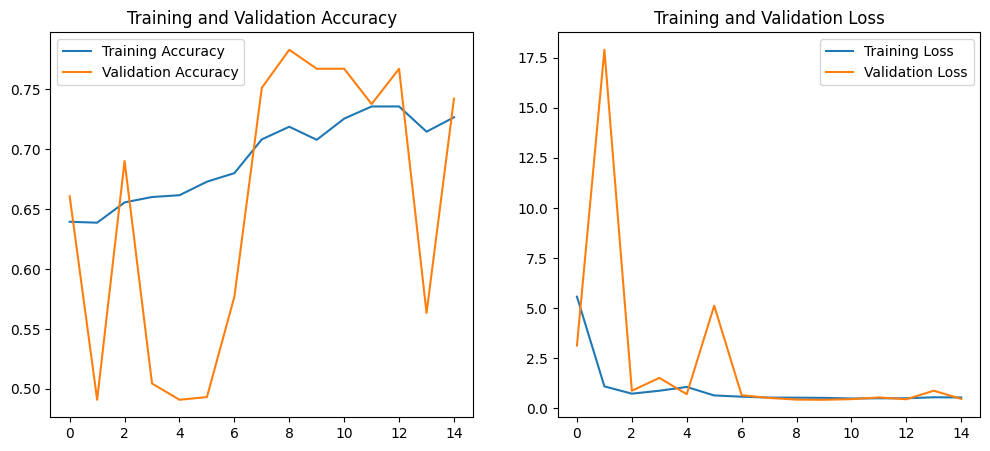

In [17]:
# 6. Model Evaluation

# 1. Plotting Accuracy and Loss Graphs

import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

# Call the function with your training history
plot_history(history)

Found 215 images belonging to 2 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step


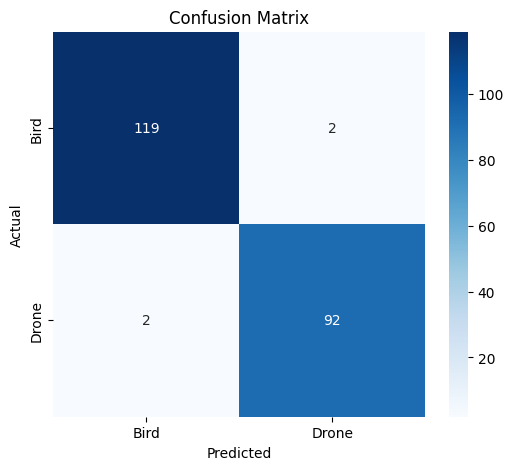

Classification Report:

              precision    recall  f1-score   support

        Bird       0.98      0.98      0.98       121
       Drone       0.98      0.98      0.98        94

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



In [18]:
# 2. Evaluation with Confusion Matrix & Classification Report

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Load the Test Data (Preprocessing only)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Crucial for matching predictions to labels
)

# 2. Get Predictions
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_generator.classes

# 3. Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bird', 'Drone'], yticklabels=['Bird', 'Drone'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 4. Print Classification Report (Precision, Recall, F1-score)
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Bird', 'Drone']))

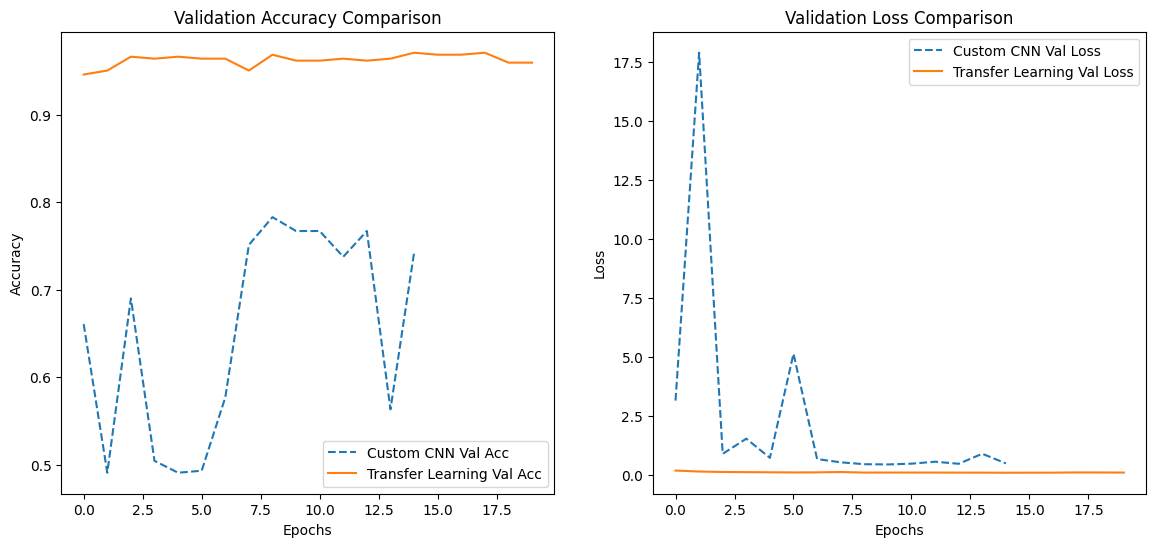

In [19]:
# 7. Model Comparison

# Side-by-Side Visualization Code

def compare_models(history_custom, history_tl):
    plt.figure(figsize=(14, 6))

    # Compare Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history_custom.history['val_accuracy'], label='Custom CNN Val Acc', linestyle='--')
    plt.plot(history_tl.history['val_accuracy'], label='Transfer Learning Val Acc')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Compare Loss
    plt.subplot(1, 2, 2)
    plt.plot(history_custom.history['val_loss'], label='Custom CNN Val Loss', linestyle='--')
    plt.plot(history_tl.history['val_loss'], label='Transfer Learning Val Loss')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Usage:
compare_models(history, history_mobilenet)

In [20]:
# Saving the Best Model for Deployment

# Save the winning model
model.save('best_bird_drone_model.keras')
print("Model saved successfully for deployment!")

Model saved successfully for deployment!


In [21]:
# Comparison & Saving Code

import pandas as pd
import matplotlib.pyplot as plt

# 1. Evaluate both models on the Test Set
# Assuming you have history_cnn and history_tl from your training steps
test_loss_cnn, test_acc_cnn = custom_model.evaluate(test_generator)
test_loss_tl, test_acc_tl = tl_model.evaluate(test_generator)

# 2. Create a Comparison Table
data = {
    'Model': ['Custom CNN', 'Transfer Learning'],
    'Test Accuracy': [test_acc_cnn, test_acc_tl],
    'Test Loss': [test_loss_cnn, test_loss_tl],
    'Training Time (Est)': ['~10 mins', '~5 mins'] # Update based on your actual logs
}
comparison_df = pd.DataFrame(data)
print(comparison_df)

# 3. Logic to Save the Best Model
if test_acc_tl > test_acc_cnn:
    print("Transfer Learning model performed better. Saving...")
    tl_model.save('best_bird_drone_model.keras')
else:
    print("Custom CNN performed better. Saving...")
    custom_model.save('best_bird_drone_model.keras')

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 317ms/step - accuracy: 0.4279 - loss: 0.6955
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 759ms/step - accuracy: 0.4186 - loss: 0.7923
               Model  Test Accuracy  Test Loss Training Time (Est)
0         Custom CNN       0.427907   0.695508            ~10 mins
1  Transfer Learning       0.418605   0.792347             ~5 mins
Custom CNN performed better. Saving...


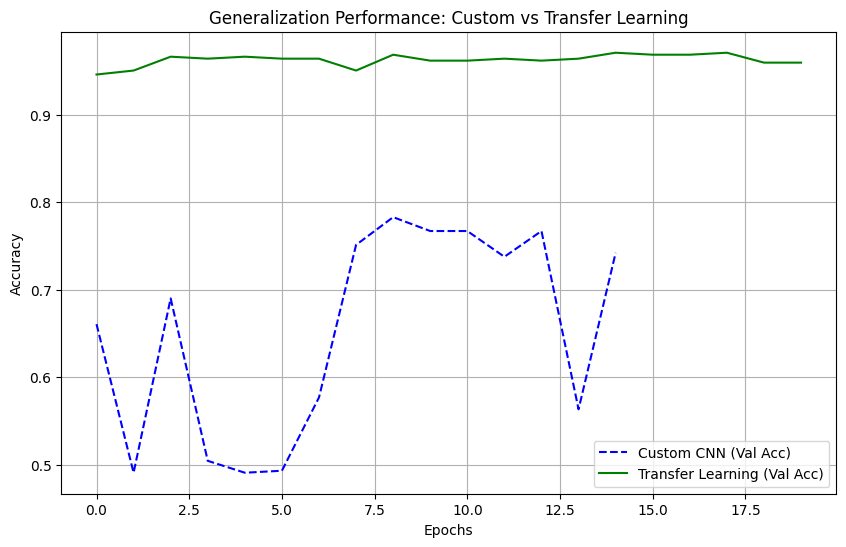

In [26]:
# Visual Comparison of Generalization

plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'], label='Custom CNN (Val Acc)', color='blue', linestyle='--')
plt.plot(history_mobilenet.history['val_accuracy'], label='Transfer Learning (Val Acc)', color='green')
plt.title('Generalization Performance: Custom vs Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [1]:
%pip install ultralytics

  Using cached ultralytics-8.4.51-py3-none-any.whl.metadata (36 kB)
  Using cached torchvision-0.27.0-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached polars-1.40.1-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.19-py3-none-any.whl.metadata (14 kB)
Using cached ultralytics-8.4.51-py3-none-any.whl (1.2 MB)
Using cached polars-1.40.1-py3-none-any.whl (828 kB)
Using cached torchvision-0.27.0-cp310-cp310-win_amd64.whl (3.4 MB)
Using cached ultralytics_thop-2.0.19-py3-none-any.whl (28 kB)

   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ------------------

In [3]:
# Optional: Object Detection with YOLOv8
# Create the data.yaml Configuration

import yaml

data_config = {
    #'train': '/content/dataset/train/images',  # Path to your training images
    #'val': '/content/dataset/valid/images',    # Path to your validation images
    #'test': '/content/dataset/test/images',    # Path to your test images (optional)
    'train': train_dir,
    'val': valid_dir,
    'test': test_dir,
    'nc': 2,                                   # Number of classes
    'names': ['Bird', 'Drone']                 # Class names in order (0=Bird, 1=Drone)
}

with open('data.yaml', 'w') as f:
    yaml.dump(data_config, f)


In [ ]:
# Train the YOLOv8 Model

from ultralytics import YOLO

# 1. Load a pretrained YOLOv8n model
model = YOLO('yolov8n.pt')

# 2. Train the model
results = model.train(
    data='data.yaml',
    epochs=50,
    imgsz=640,       # YOLOv8 standard size is 640
    batch=16,
    name='bird_drone_detection'
)

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\bless\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51  Python-3.10.19 torch-2.12.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hs

In [ ]:
# Validate the Trained Model

# Validate the model on the validation set
metrics = model.val()

print(f"Mean Average Precision (mAP50): {metrics.box.map50}")

In [ ]:
# Run Inference (Detection)

# Run detection on a test image
sample_img = os.path.join(base_dir, 'sample.jpg')
#results = model.predict(source='/content/dataset/test/images/sample.jpg', save=True, conf=0.5)
results = model.predict(source=sample_img, save=True, conf=0.5)

# Show the results
for result in results:
    result.show()  # Opens the image with boxes drawn

In [1]:
%pip install streamlit

In [2]:
%pip install streamlit ultralytics tensorflow pillow

In [1]:
%%writefile app.py
import os
import streamlit as st
import tensorflow as tf
from ultralytics import YOLO
from PIL import Image
import numpy as np

# --- 1. Load Models ---
@st.cache_resource # Keeps models in memory for speed
def load_models():
    base_dir = 'D:/Python_Code/Projects_In_Course_Time/Project-5_AerialObjectClassification&Detection/'
    best_bird_drone_model_dir = os.path.join(base_dir, 'best_model.keras')
    # Load your saved classification model (Step 7)
    classifier = tf.keras.models.load_model(best_bird_drone_model_dir)
    
    # Load your trained YOLOv8 model (Step 8)
    #bird_drone_detection = os.path.join(base_dir, 'runs/detect/bird_drone_detection/weights/best.pt')
    #detector = YOLO(bird_drone_detection)
    #return classifier, detector
    return classifier

#classifier, detector = load_models()
classifier = load_models()


# --- 2. Simple UI ---
st.title("🦅 Aerial Object Sentinel")
st.write("Upload an aerial image to classify and detect Birds vs. Drones.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image', use_container_width=True)

    st.write("---")
    col1, col2 = st.columns(2)

    # --- 3. Run Classification (Step 4 & 6) ---
    with col1:
        st.subheader("Classification Results")
        # Preprocess for CNN (Resize 224x224 & Normalize [0,1])
        img_resized = image.resize((224, 224))
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        #prediction = classifier.predict(img_array)[0][0]
        prediction = classifier.predict(img_array, verbose=0)[0][0]
        label = "Drone" if prediction > 0.5 else "Bird"
        confidence = prediction if label == "Drone" else (1 - prediction)

        st.metric(label=f"Detected: {label}", value=f"{confidence*100:.2f}% Confidence")

    # --- 4. Run YOLOv8 Detection (Optional Step) ---
    #with col2:
        #st.subheader("Object Detection")
        # Run YOLO inference
        #results = detector(image)

        # Plot results back onto the image
        #res_plotted = results[0].plot()
        #st.image(res_plotted, caption='YOLOv8 Bounding Boxes', use_container_width=True)

Overwriting app.py


In [ ]:
!streamlit run app.py